In [1]:
import os
from dotenv import load_dotenv

# 加载 .env 环境变量
load_dotenv(override=True)

# 取消 socks5 代理，避免 httpx 报错 missing socksio
os.environ.pop("all_proxy", None)
os.environ.pop("ALL_PROXY", None)

# 开启 LangSmith 跟踪（需在 .env 配置 LANGCHAIN_API_KEY）
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ChatBot"

In [2]:
import json
from typing import Annotated, Literal
from typing_extensions import TypedDict
from pydantic import SecretStr

from langchain_core.messages import BaseMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# 定义状态类型：messages 使用 add_messages 将新消息追加到现有列表
class State(TypedDict):
    messages: Annotated[list, add_messages]

/Users/deer/workspace/jk_code/openai-quickstart/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/deer/workspace/jk_code/openai-quickstart/.venv/lib/python3.13/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
# 从 .env 读取模型配置（DeepSeek）
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
OPENAI_API_BASE = os.getenv("OPENAI_API_BASE", "")

# 初始化 ChatOpenAI 模型
chat_model = ChatOpenAI(model="deepseek-chat", api_key=SecretStr(OPENAI_API_KEY), base_url=OPENAI_API_BASE)

# 定义 Tavily 搜索工具，最大搜索结果数设置为 2
tool = TavilySearchResults(max_results=2)
tools = [tool]

# 将工具绑定到 LLM，使其在需要时调用搜索工具
llm_with_tools = chat_model.bind_tools(tools)

In [ ]:
# 工具调试：验证 TAVILY_API_KEY 是否配置正确（需在 .env 配置）
# tool.invoke("2026年7月31日 中国a股行情")

In [4]:
# 定义聊天节点：调用绑定了工具的 LLM
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 定义 BasicToolNode，执行最后一条 AI 消息中的工具请求
class BasicToolNode:
    """一个在最后一条 AIMessage 中执行工具请求的节点。"""

    def __init__(self, tools: list) -> None:
        # 通过工具名称映射到具体工具
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        """执行工具调用并返回 ToolMessage 列表"""
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("输入中未找到消息")

        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


# 定义路由函数：根据最后一条消息是否包含工具调用决定下一步
def route_tools(state: State) -> Literal["tools", "__end__"]:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"输入状态中未找到消息: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

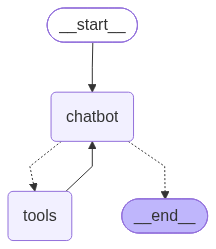

In [5]:
graph_builder = StateGraph(State)

# 添加聊天节点与工具节点
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", BasicToolNode(tools=tools))

# 从 chatbot 出发：有工具调用走 tools，否则结束
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", "__end__": "__end__"},
)
# 工具执行完成后返回聊天节点继续对话
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 编译状态图，生成可执行的流程图
graph = graph_builder.compile()

# 可视化状态图
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
# 进入一个无限循环，模拟持续的对话
while True:
    # 获取用户输入
    user_input = input("User: ")

    # 输入 "quit"、"exit" 或 "q" 则退出循环
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 使用 graph.stream 处理用户输入，并生成机器人的回复
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print("Assistant:", value["messages"][-1].content)

Assistant: 我来帮您搜索2026年中国大陆上映的电影信息。
Assistant: [{"url": "https://www.incgmedia.com/spotlight/2026-movie-list", "content": "## \u300a\u529f\u592b\u300b\uff08Kunfu\uff09\n\n\u767c\u884c\u516c\u53f8\uff1a\u9ebb\u5409\u7825\u52a0\n\n\u4e0a\u6620\u65e5\u671f\uff1a2026 \u5e74 2 \u6708 13 \u65e5\n\n\u8017\u6642\u5169\u5e74\u62cd\u651d\uff0c\u65a5\u8cc7\u8fd1\u4e09\u5104\u53f0\u5e63\uff0c\u6539\u7de8\u81ea\u4e5d\u628a\u5200\u300a\u90fd\u5e02\u6050\u6016\u75c5\u300b\u7cfb\u5217\u540c\u540d\u5c0f\u8aaa\uff0c\u6234\u7acb\u5fcd\u3001\u67ef\u9707\u6771\u3001\u6731\u8ed2\u6d0b\u3001\u738b\u6de8\u3001\u5289\u51a0\u5ef7\u4e3b\u6f14\uff0c\u66fe\u839e\u5a77\u3001\u9ad8\u82f1\u8ed2\u3001\u9ec3\u8fea\u63da\u3001\u56b4\u85dd\u6587\u7b49\u4eba\u7279\u5225\u6f14\u51fa\u3002\u5287\u60c5\u63cf\u8ff0\u9b6f\u86c7\u9ad8\u4e2d\u751f\u6df5\u4ed4\uff08\u67ef\u9707\u6771 \u98fe\uff09\u8ddf\u963f\u7fa9\uff08\u6731\u8ed2\u6d0b \u98fe\uff09 \u9047\u4e0a\u4e86\u8eab\u61f7\u84cb\u4e16\u6b66\u529f\u7684\u6d41\u6d6a\u6f22\u9

KeyboardInterrupt: Interrupted by user